In [1]:
from typing import List, Literal
from typing_extensions import TypedDict

from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

from models import get_model, get_embeddings
from pdf_chunk import text_spliter

e:\Rohanta_AI_workbook\adavance_RAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm             = get_model()
embedding_model = get_embeddings()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3296.08it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
vectorstore = Chroma.from_documents(
    text_spliter,
    embedding_model,
    collection_name="self_rag"
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

In [4]:
class SelfRAGState(TypedDict):
    question    : str
    documents   : List[Document]
    generation  : str
    retry_count : int
    isuse_score : int 

In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — The 4 reflection chains
# ════════════════════════════════════════════════════════════════

# ── [Retrieve] token ─────────────────────────────────────────
retrieve_token_prompt = ChatPromptTemplate.from_template("""
Decide if you need to retrieve external documents to answer this question,
or if you can answer from general knowledge alone.

Answer ONLY "yes" (need retrieval) or "no" (can answer directly).

Question: {question}
Decision:
""")
retrieve_token_chain = retrieve_token_prompt | llm | StrOutputParser()

# ── [IsREL] token ────────────────────────────────────────────
isrel_prompt = ChatPromptTemplate.from_template("""
[IsREL] Is this document relevant to answer the question?
Answer ONLY "relevant" or "irrelevant".

Question: {question}
Document: {document}
Score:
""")
isrel_chain = isrel_prompt | llm | StrOutputParser()

# ── [IsSUP] token ────────────────────────────────────────────
issup_prompt = ChatPromptTemplate.from_template("""
[IsSUP] Is this answer fully supported by the documents provided?
Answer ONLY:
- "fully"   — answer is completely grounded in the documents
- "partial" — answer is mostly grounded but has some unsupported claims
- "no"      — answer contains claims not found in the documents

Documents: {documents}
Answer: {generation}
Score:
""")
issup_chain = issup_prompt | llm | StrOutputParser()

# ── [IsUSE] token ────────────────────────────────────────────
isuse_prompt = ChatPromptTemplate.from_template("""
[IsUSE] Rate how useful this answer is for the user's question.
Score from 1 (not useful) to 5 (perfectly useful).
Answer ONLY with a single digit: 1, 2, 3, 4, or 5.

Question: {question}
Answer: {generation}
Score:
""")
isuse_chain = isuse_prompt | llm | StrOutputParser()

# ── Answer generator ─────────────────────────────────────────
answer_prompt = ChatPromptTemplate.from_template("""
Answer the question using only the context below.
Be factual and concise. If the answer is not in the context, say "I don't know".

Context: {context}
Question: {question}
Answer:
""")
answer_chain = answer_prompt | llm | StrOutputParser()

# ── Direct answer (no retrieval) ─────────────────────────────
direct_prompt = ChatPromptTemplate.from_template("""
Answer this question using your own knowledge. Be concise and factual.

Question: {question}
Answer:
""")
direct_chain = direct_prompt | llm | StrOutputParser()

In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Node functions
# ════════════════════════════════════════════════════════════════
MAX_RETRIES    = 3
MIN_ISUSE_SCORE = 4    # minimum acceptable utility score

def decide_retrieval(state: SelfRAGState) -> dict:
    """Node: [Retrieve] token — should we retrieve at all?"""
    print("\n--- NODE: [Retrieve] decision ---")
    decision = retrieve_token_chain.invoke({
        "question": state["question"]
    }).strip().lower()
    print(f"  Retrieve needed: {decision}")
    # Store decision in documents as a signal (empty = no retrieve)
    return {
        "documents"  : [] if "no" in decision else None,
        "retry_count": 0
    }


def retrieve(state: SelfRAGState) -> dict:
    """Node: retrieve docs from Chroma."""
    print("--- NODE: retrieve ---")
    docs = retriever.invoke(state["question"])
    print(f"  Retrieved {len(docs)} docs")
    return {"documents": docs}


def grade_relevance(state: SelfRAGState) -> dict:
    """Node: [IsREL] — filter to only relevant docs."""
    print("--- NODE: [IsREL] relevance grading ---")
    question     = state["question"]
    relevant     = []

    for doc in state["documents"]:
        score = isrel_chain.invoke({
            "question": question,
            "document": doc.page_content
        }).strip().lower()

        if "relevant" in score:
            relevant.append(doc)
            print(f"  [IsREL]=relevant : {doc.page_content[:55]}...")
        else:
            print(f"  [IsREL]=irrel.   : {doc.page_content[:55]}...")

    return {"documents": relevant}


def generate(state: SelfRAGState) -> dict:
    """Node: generate answer from relevant docs."""
    print("--- NODE: generate ---")
    context = "\n\n".join([d.page_content for d in state["documents"]])
    answer  = answer_chain.invoke({
        "question": state["question"],
        "context" : context
    })
    print(f"  Generated: {answer[:80]}...")
    return {"generation": answer}


def generate_direct(state: SelfRAGState) -> dict:
    """Node: answer directly without retrieval."""
    print("--- NODE: generate_direct (no retrieval) ---")
    answer = direct_chain.invoke({"question": state["question"]})
    print(f"  Direct answer: {answer[:80]}...")
    return {"generation": answer}


def score_utility(state: SelfRAGState) -> dict:
    """Node: [IsUSE] — score answer utility 1-5."""
    print("--- NODE: [IsUSE] utility scoring ---")
    raw = isuse_chain.invoke({
        "question"  : state["question"],
        "generation": state["generation"]
    }).strip()

    # Extract digit safely
    score = next((int(c) for c in raw if c.isdigit()), 3)
    print(f"  [IsUSE] score = {score}/5")
    return {"isuse_score": score}

In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Conditional edge functions
# ════════════════════════════════════════════════════════════════

def decide_after_retrieve_token(
    state: SelfRAGState
) -> Literal["retrieve", "generate_direct"]:
    """After [Retrieve] decision: fetch docs or answer directly?"""
    # Empty documents list signals 'no retrieval needed'
    if state.get("documents") is not None and len(state["documents"]) == 0:
        return "generate_direct"
    return "retrieve"


def decide_after_relevance(
    state: SelfRAGState
) -> Literal["generate", "retrieve"]:
    """After [IsREL]: enough relevant docs or retry?"""
    if not state["documents"]:
        retry = state.get("retry_count", 0)
        if retry >= MAX_RETRIES:
            print("  Max retries hit — forcing generate with empty context")
            return "generate"
        return "retrieve"          # re-retrieve
    return "generate"


def decide_after_generation(
    state: SelfRAGState
) -> Literal["score_utility", "generate"]:
    """After generate: check [IsSUP] groundedness."""
    print("--- EDGE: [IsSUP] groundedness check ---")
    docs_text = "\n\n".join([d.page_content for d in state["documents"]])
    score = issup_chain.invoke({
        "documents" : docs_text,
        "generation": state["generation"]
    }).strip().lower()

    print(f"  [IsSUP] = {score}")

    if "no" in score:
        retry = state.get("retry_count", 0)
        if retry >= MAX_RETRIES:
            return "score_utility"   # give up, score anyway
        # Increment retry and go back to generate
        state["retry_count"] = retry + 1
        return "generate"
    return "score_utility"


def decide_after_utility(
    state: SelfRAGState
) -> Literal[END, "retrieve"]:
    """After [IsUSE]: is score good enough or try again?"""
    score = state.get("isuse_score", 3)
    retry = state.get("retry_count", 0)

    if score >= MIN_ISUSE_SCORE:
        print(f"  [IsUSE]={score} ≥ {MIN_ISUSE_SCORE} → accepting answer")
        return END
    elif retry >= MAX_RETRIES:
        print(f"  Max retries hit, accepting score={score}")
        return END
    else:
        print(f"  [IsUSE]={score} < {MIN_ISUSE_SCORE} → retrying retrieval")
        state["retry_count"] = retry + 1
        return "retrieve"

In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Build the LangGraph
# ════════════════════════════════════════════════════════════════
builder = StateGraph(SelfRAGState)

# ── Nodes ────────────────────────────────────────────────────
builder.add_node("decide_retrieval", decide_retrieval)
builder.add_node("retrieve",         retrieve)
builder.add_node("grade_relevance",  grade_relevance)
builder.add_node("generate",         generate)
builder.add_node("generate_direct",  generate_direct)
builder.add_node("score_utility",    score_utility)

# ── Fixed edges ──────────────────────────────────────────────
builder.add_edge(START,              "decide_retrieval")
builder.add_edge("retrieve",         "grade_relevance")
builder.add_edge("generate_direct",  "score_utility")

# ── Conditional edges ────────────────────────────────────────
builder.add_conditional_edges(
    "decide_retrieval",
    decide_after_retrieve_token,
    {"retrieve": "retrieve", "generate_direct": "generate_direct"}
)

builder.add_conditional_edges(
    "grade_relevance",
    decide_after_relevance,
    {"generate": "generate", "retrieve": "retrieve"}
)

builder.add_conditional_edges(
    "generate",
    decide_after_generation,
    {"score_utility": "score_utility", "generate": "generate"}
)

builder.add_conditional_edges(
    "score_utility",
    decide_after_utility,
    {END: END, "retrieve": "retrieve"}
)

# ── Compile ──────────────────────────────────────────────────
memory         = MemorySaver()
self_rag_graph = builder.compile(checkpointer=memory)


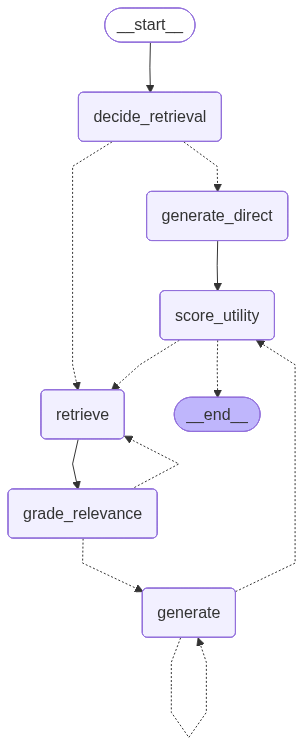

In [9]:
self_rag_graph

In [10]:
def run_self_rag(question: str, thread_id: str = "default") -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = self_rag_graph.invoke(
        {"question": question, "retry_count": 0, "isuse_score": 0},
        config=config
    )
    print(f"\n{'═'*60}")
    print(f"FINAL ANSWER: {result.get('generation', 'No answer')}")
    print(f"IsUSE score : {result.get('isuse_score', '?')}/5")
    print(f"{'═'*60}")
    return result.get("generation", "")

In [11]:
run_self_rag("What is Rohanta's current university?")


--- NODE: [Retrieve] decision ---
  Retrieve needed: no
--- NODE: generate_direct (no retrieval) ---
  Direct answer: I don't have information on Rohanta's current university....
--- NODE: [IsUSE] utility scoring ---
  [IsUSE] score = 2/5
  [IsUSE]=2 < 4 → retrying retrieval
--- NODE: retrieve ---
  Retrieved 4 docs
--- NODE: [IsREL] relevance grading ---
  [IsREL]=relevant : Before transitioning fully into industry, Rohanta taugh...
  [IsREL]=relevant : Rohanta Bhamare is an AI Engineer with 5+ years of expe...
  [IsREL]=relevant : Role: Assistant Professor
Institution: Guru Gobind Sing...
  [IsREL]=relevant : IDENTITY AND CONTACT

Full Name: Rohanta Dinkar Bhamare...
--- NODE: generate ---
  Generated: I don't know....
--- EDGE: [IsSUP] groundedness check ---
  [IsSUP] = "no"
--- NODE: generate ---
  Generated: I don't know....
--- EDGE: [IsSUP] groundedness check ---
  [IsSUP] = "no"
--- NODE: generate ---
  Generated: I don't know....
--- EDGE: [IsSUP] groundedness check ---
  [Is

KeyboardInterrupt: 

In [12]:
run_self_rag("What is Python programming language?")


--- NODE: [Retrieve] decision ---
  Retrieve needed: no
--- NODE: generate_direct (no retrieval) ---
  Direct answer: Python is a high-level, interpreted programming language that is widely used for...
--- NODE: [IsUSE] utility scoring ---
  [IsUSE] score = 5/5
  [IsUSE]=5 ≥ 4 → accepting answer

════════════════════════════════════════════════════════════
FINAL ANSWER: Python is a high-level, interpreted programming language that is widely used for various purposes such as:

1. Web development (e.g., Django, Flask)
2. Data analysis and science (e.g., NumPy, pandas, scikit-learn)
3. Artificial intelligence and machine learning (e.g., TensorFlow, Keras)
4. Automation and scripting
5. Scientific computing and research

Python is known for its simplicity, readability, and ease of use, making it a popular choice among beginners and experienced developers alike.
IsUSE score : 5/5
════════════════════════════════════════════════════════════


'Python is a high-level, interpreted programming language that is widely used for various purposes such as:\n\n1. Web development (e.g., Django, Flask)\n2. Data analysis and science (e.g., NumPy, pandas, scikit-learn)\n3. Artificial intelligence and machine learning (e.g., TensorFlow, Keras)\n4. Automation and scripting\n5. Scientific computing and research\n\nPython is known for its simplicity, readability, and ease of use, making it a popular choice among beginners and experienced developers alike.'